## Extended Kalman Filter

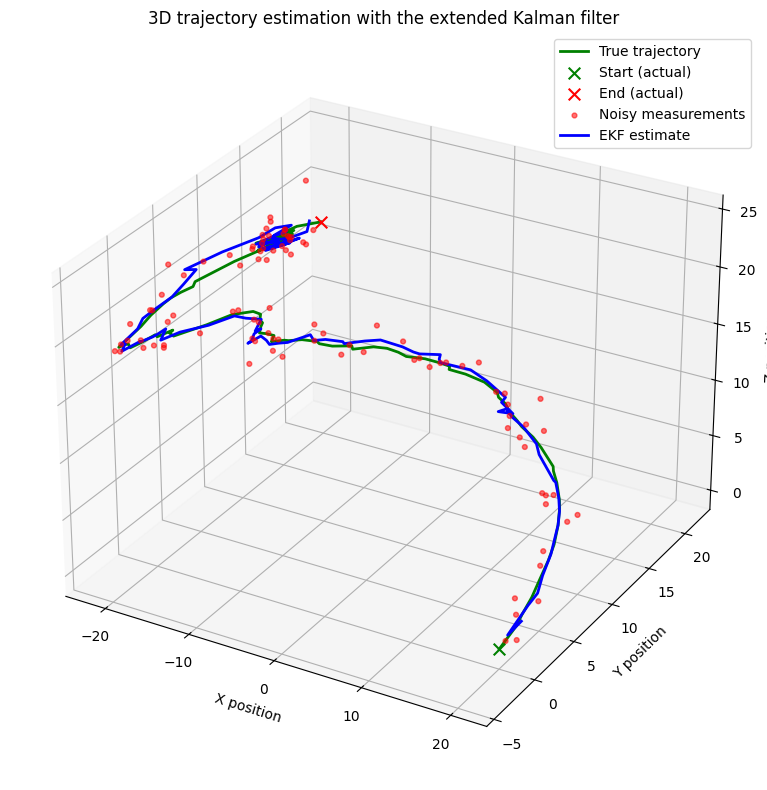

In [21]:
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D plotting

rng = np.random.default_rng(7)

# EKF example: latent angular motion with nonlinear observation
# State: [theta, omega, z, vz]
# Observation: [x, y, z] = [R cos(theta), R sin(theta), z]


T = 100
dt = 1.0
radius = 20.0
obs_std = 1.0

# Linear latent dynamics
F = np.array([
    [1.0, dt, 0.0, 0.0],
    [0.0, 1.0, 0.0, 0.0],
    [0.0, 0.0, 1.0, dt ],
    [0.0, 0.0, 0.0, 1.0],
])

Q = np.diag([0.002, 0.0003, 0.02, 0.002])
R = (obs_std**2) * np.eye(3)

def wrap_angle(theta):
    return (theta + np.pi) % (2 * np.pi) - np.pi

def f_helix(s):
    return F @ s

def h_helix(s):
    theta, omega, z, vz = s
    return np.array([
        radius * np.cos(theta),
        radius * np.sin(theta),
        z
    ])

def H_jacobian(s):
    theta, omega, z, vz = s
    return np.array([
        [-radius * np.sin(theta), 0.0, 0.0, 0.0],
        [ radius * np.cos(theta), 0.0, 0.0, 0.0],
        [0.0,                     0.0, 1.0, 0.0],
    ])

# Simulate true latent states
states_true = np.zeros((T, 4))
states_true[0] = np.array([0.0, 0.10, 0.0, 0.5])

for t in range(T - 1):
    w = rng.multivariate_normal(np.zeros(4), Q)
    states_true[t + 1] = f_helix(states_true[t]) + w
    states_true[t + 1, 0] = wrap_angle(states_true[t + 1, 0])

theta_true = states_true[:, 0]
true_z = states_true[:, 2]
true_x = radius * np.cos(theta_true)
true_y = radius * np.sin(theta_true)

# Noisy Cartesian observations
xs_3d = np.column_stack([
    true_x + rng.normal(0.0, obs_std, size=T),
    true_y + rng.normal(0.0, obs_std, size=T),
    true_z + rng.normal(0.0, obs_std, size=T),
])

# EKF initialisation
m_filt = np.zeros((T, 4))
C_filt = np.zeros((T, 4, 4))

m_filt[0] = np.array([0.15, 0.08, xs_3d[0, 2], 0.45])
C_filt[0] = np.diag([0.15, 0.01, 1.0, 0.08])

I4 = np.eye(4)

for t in range(T - 1):
    m_t = m_filt[t]
    C_t = C_filt[t]

    # Prediction
    m_hat = f_helix(m_t)
    C_hat = F @ C_t @ F.T + Q

    # Update
    H_t = H_jacobian(m_hat)
    innovation = xs_3d[t + 1] - h_helix(m_hat)

    S = H_t @ C_hat @ H_t.T + R
    K = C_hat @ H_t.T @ np.linalg.inv(S)

    m_new = m_hat + K @ innovation
    m_new[0] = wrap_angle(m_new[0])

    C_new = (I4 - K @ H_t) @ C_hat @ (I4 - K @ H_t).T + K @ R @ K.T
    C_new = 0.5 * (C_new + C_new.T)

    m_filt[t + 1] = m_new
    C_filt[t + 1] = C_new

# Convert EKF state means into Cartesian coordinates
theta_est = m_filt[:, 0]
z_est = m_filt[:, 2]

x_est = radius * np.cos(theta_est)
y_est = radius * np.sin(theta_est)

# Push EKF covariance into Cartesian position space for ellipsoid plotting
means_xyz = np.zeros((T, 6))
covs_xyz = np.zeros((T, 6, 6))

for t in range(T):
    means_xyz[t, 0] = x_est[t]
    means_xyz[t, 2] = y_est[t]
    means_xyz[t, 4] = z_est[t]

    H_t = H_jacobian(m_filt[t])
    Cpos = H_t @ C_filt[t] @ H_t.T

    covs_xyz[t][np.ix_([0, 2, 4], [0, 2, 4])] = Cpos

# Plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

ax.plot(true_x, true_y, true_z, color="green", linewidth=2.0, label="True trajectory")
ax.scatter(true_x[0], true_y[0], true_z[0], color="green", marker="x", s=70, label="Start (actual)")
ax.scatter(true_x[-1], true_y[-1], true_z[-1], color="red", marker="x", s=70, label="End (actual)")

ax.scatter(
    xs_3d[:, 0], xs_3d[:, 1], xs_3d[:, 2],
    color="red", s=12, alpha=0.55, depthshade=True,
    label="Noisy measurements"
)

ax.plot(x_est, y_est, z_est, color="blue", linewidth=2.0, label="EKF estimate")

ax.set_xlabel("X position")
ax.set_ylabel("Y position")
ax.set_zlabel("Z position")
ax.set_title("3D trajectory estimation with the extended Kalman filter")
ax.view_init(elev=28, azim=-60)
ax.legend()


plt.tight_layout()
plt.show()